In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [3]:
IEA_policies_df = pd.read_csv(os.path.join(iea_data_dir_path, 'IEA_PAMS_Export 1_29_2025, 6_11_31 PM.csv'))
IEA_policies_df

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13150,1996.0,National,Voluntary Energy Audits,The Grand Ducal regulation of 11 August 1996 o...,In force,LUX,Luxembourg,NaN,NaN,NaN,NaN
13151,2008.0,National,Carbon Emissions Reduction Target (Energy Effi...,The Carbon Emissions Reduction Target (CERT) -...,Ended,GBR,United Kingdom,NaN,NaN,NaN,https://www.ofgem.gov.uk/environmental-program...
13152,2009.0,National,Saving energy by the organizations of local au...,The programmes concern the implementation of i...,Ended,GRC,Greece,NaN,NaN,NaN,NaN
13153,2006.0,National,Public Transit Capital Trust,Canada's Federal Budget 2006 dedicated CAD 1.3...,In force,CAN,Canada,NaN,NaN,NaN,NaN


In [4]:
# Make all col names lowercase
IEA_policies_df.columns = IEA_policies_df.columns.str.lower()

# drop source column
IEA_policies_df = IEA_policies_df.drop(columns=['source'])

## Data Integrity and Initial Cleaning

### Missing data in important columns
- year.
- iso3.

In [5]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13127 non-null  float64
 1   jurisdiction  13155 non-null  object 
 2   title         13155 non-null  object 
 3   description   13119 non-null  object 
 4   status        13155 non-null  object 
 5   iso3          13149 non-null  object 
 6   country       13155 non-null  object 
 7   topic         7046 non-null   object 
 8   type          7046 non-null   object 
 9   category      3630 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.0+ MB


In [6]:
# Check for duplicates
duplicates = IEA_policies_df.duplicated()
duplicates.value_counts()

False    12739
True       416
Name: count, dtype: int64

In [7]:
# Eliminate duplicates
IEA_policies_df = IEA_policies_df.drop_duplicates()

In [8]:
# Check for NaN in year column
IEA_policies_df['year'].isnull().value_counts()

year
False    12712
True        27
Name: count, dtype: int64

In [9]:
# Print null cols where year is null
# IEA_policies_df[IEA_policies_df['year'].isnull()]

In [10]:
# For now let's drop the rows with NaN in year column
IEA_policies_df = IEA_policies_df.dropna(subset=['year'])

In [11]:
# set year column to integer
IEA_policies_df['year'] = IEA_policies_df['year'].astype(int)

In [12]:
# Check for NaN in iso3 column
IEA_policies_df['iso3'].isnull().value_counts()

iso3
False    12707
True         5
Name: count, dtype: int64

In [13]:
IEA_policies_df[IEA_policies_df['iso3'].isnull()]

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
226,2013,International,Climate Technology Centre and Network Technica...,The Climate Technology Centre and Network (CTC...,In force,NaN,Unknown,NaN,NaN,NaN
229,2009,International,The World Bank Carbon Capture and Storage Capa...,"The World Bank CCS Trust Fund, established in ...",In force,NaN,Unknown,NaN,NaN,NaN
3325,2015,International,The Vatican’s Laudato Si’ Action Platform,Pope Francis issued the Laudato Si’ encyclical...,In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Socioeconomic development,,Public participation,",NaN
3342,2008,National,Vatican installation of PV system,"To help green its operations, as promoted by P...",In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Energy security and resilience,,Public partici...",NaN
5019,2019,International,LEAP-RE,LEAP-RE is a mechanism for funding R&amp;D and...,In force,NaN,African Union,Technology R&D and innovation,"Grants,Resource push",Grants for R&D projects


In [14]:
# Drop rows with NaN in iso3 column
IEA_policies_df = IEA_policies_df.dropna(subset=['iso3'])

In [15]:
# Check jurisdiction column
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional', 'National '], dtype=object)

In [16]:
# Replace the 'National ' values to 'National' in the jurisdiction column
IEA_policies_df.loc[IEA_policies_df['jurisdiction'] == 'National ', 'jurisdiction'] = 'National'

In [17]:
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional'], dtype=object)

In [18]:
# Filter the years to match the emissions data
IEA_policies_df = IEA_policies_df[(IEA_policies_df['year'] >= 2000) & (IEA_policies_df['year'] <= 2022)]

In [19]:
# Check for repeated values in title column

# Group by title and collect the years for each title
duplicates = IEA_policies_df.groupby('title')['year'].unique().reset_index()

# Filter for titles that appear in more than one year
duplicated_titles = duplicates[duplicates['year'].apply(lambda x: len(x) > 1)]
duplicated_titles


,title,year
786,Bio-energy Infrastructure Scheme,"[2004, 2003]"
827,Biofuels blending mandate,"[2013, 2011]"
902,Building Code of Australia (Non-residential B...,"[2013, 2014]"
904,Building Code of Australia (Multi-Occupancy Bu...,"[2012, 2013, 2014, 2015]"
909,Building Code of Australia (Residential Building),"[2012, 2013, 2014, 2016]"
1295,Climate Change Agreements,"[2001, 2014]"
1423,Company tax benefits,"[2017, 2018]"
1836,ENERGY STAR for New Homes,"[2005, 2017]"
2128,Emissions Reduction Fund,"[2020, 2017]"
2210,Energy Efficiency Fund,"[2010, 2011, 2012, 2009, 2014]"


In [20]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9596 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          9596 non-null   int64 
 1   jurisdiction  9596 non-null   object
 2   title         9596 non-null   object
 3   description   9570 non-null   object
 4   status        9596 non-null   object
 5   iso3          9596 non-null   object
 6   country       9596 non-null   object
 7   topic         4289 non-null   object
 8   type          4289 non-null   object
 9   category      2388 non-null   object
dtypes: int64(1), object(9)
memory usage: 824.7+ KB


In [21]:
# Fill NaNs with Unknown
IEA_policies_df = IEA_policies_df.fillna('Unknown')

## Understanding the Data

- Num of regions: 217


In [22]:
# How many countries we have?
IEA_policies_df['country'].unique()

array(['Morocco', 'Switzerland', 'Germany', 'Finland', 'Greece',
       'Netherlands', "People's Republic of China", 'Turkiye', 'France',
       'United States', 'New Zealand', 'Canada', 'Norway', 'Spain',
       'Luxembourg', 'Sweden', 'Australia', 'Italy',
       'United Arab Emirates', 'United Kingdom', 'Portugal', 'Tunisia',
       'Korea', 'Hungary', 'Japan', 'Russian Federation',
       'European Union', 'Turkmenistan', 'Singapore', 'India',
       'Lithuania', 'Poland', 'Denmark', 'Mexico', 'Brazil', 'Viet Nam',
       'Bolivarian Republic of Venezuela', 'Argentina', 'Israel',
       'Ukraine', 'Costa Rica', 'Peru', 'Jordan', 'Malaysia', 'Uruguay',
       'Saudi Arabia', 'Ghana', 'Pakistan', 'Belarus', 'Panama',
       'Tajikistan', 'Armenia', 'Barbados', 'Kenya', 'Nigeria', 'Iceland',
       'Mauritius', 'Zimbabwe', 'Azerbaijan', 'Philippines', 'Angola',
       'Ethiopia', 'Namibia', 'Jamaica', 'Afghanistan', 'Bahrain',
       'Benin', 'Bangladesh', 'Bhutan', 'Algeria',
       

In [23]:
# Print the amount of countries
len(IEA_policies_df['country'].unique())

215

In [24]:
# How many policies each country has?
policies_per_country_df = IEA_policies_df['country'].value_counts().reset_index()
policies_per_country_df.columns = ['country', 'policy_count']
policies_per_country_df



,country,policy_count
0,United States,624
1,Australia,383
2,Canada,371
3,People's Republic of China,349
4,United Kingdom,312
...,...,...
210,French Polynesia,1
211,British Indian Ocean Territory,1
212,Netherlands Antilles,1
213,State of Palestine,1


In [25]:
# Add max year and min year for each country
max_year_per_country = IEA_policies_df.groupby('country')['year'].max().reset_index()
min_year_per_country = IEA_policies_df.groupby('country')['year'].min().reset_index()
max_year_per_country.columns = ['country', 'max_year']
min_year_per_country.columns = ['country', 'min_year']

In [26]:
max_year_per_country.head()

,country,max_year
0,Afghanistan,2021
1,Albania,2022
2,Algeria,2022
3,Andorra,2021
4,Angola,2021


In [27]:
min_year_per_country.head()

,country,min_year
0,Afghanistan,2006
1,Albania,2002
2,Algeria,2003
3,Andorra,2016
4,Angola,2000


In [28]:
# merge max year and min year with policies_per_country_df
policies_per_country_df = policies_per_country_df.merge(max_year_per_country, on='country')
policies_per_country_df = policies_per_country_df.merge(min_year_per_country, on='country')

# add iso3
policies_per_country_df = policies_per_country_df.merge(IEA_policies_df[['country', 'iso3']].drop_duplicates(), on='country')
policies_per_country_df

,country,policy_count,max_year,min_year,iso3
0,United States,624,2022,2000,USA
1,Australia,383,2022,2000,AUS
2,Canada,371,2022,2000,CAN
3,People's Republic of China,349,2022,2001,CHN
4,United Kingdom,312,2022,2000,GBR
...,...,...,...,...,...
210,French Polynesia,1,2014,2014,PYF
211,British Indian Ocean Territory,1,2014,2014,IOT
212,Netherlands Antilles,1,2014,2014,ANT
213,State of Palestine,1,2005,2005,PSE


In [29]:
# Pivot the jurisdiction column to create new columns for each unique jurisdiction
jusrisdiction_pivot_df = IEA_policies_df.pivot_table(index='country', columns='jurisdiction', values='title', aggfunc='count', fill_value=0).reset_index()

# Merge the pivoted dataframe with policies_per_country_df
policies_per_country_df = policies_per_country_df.merge(jusrisdiction_pivot_df, on='country', how='left')

policies_per_country_df

,country,policy_count,max_year,min_year,iso3,City/Municipal,International,National,Other,Regional,State/Provincial,Unknown
0,United States,624,2022,2000,USA,3,42,397,0,0,180,2
1,Australia,383,2022,2000,AUS,1,31,268,0,1,82,0
2,Canada,371,2022,2000,CAN,18,23,236,0,0,94,0
3,People's Republic of China,349,2022,2001,CHN,9,10,311,0,1,17,1
4,United Kingdom,312,2022,2000,GBR,6,20,271,0,0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...
210,French Polynesia,1,2014,2014,PYF,0,1,0,0,0,0,0
211,British Indian Ocean Territory,1,2014,2014,IOT,0,1,0,0,0,0,0
212,Netherlands Antilles,1,2014,2014,ANT,0,1,0,0,0,0,0
213,State of Palestine,1,2005,2005,PSE,0,1,0,0,0,0,0


In [30]:
policies_per_country_df.to_csv(os.path.join(iea_data_dir_path, 'IEA_policies_per_country.csv'), index=False)

In [31]:
# Pivot the status column to create new columns for each unique status
status_pivot_df = IEA_policies_df.pivot_table(index='country', columns='status', values='title', aggfunc='count', fill_value=0).reset_index()

# Merge the pivoted dataframe with policies_per_country_df
policies_per_country_df = policies_per_country_df.merge(status_pivot_df, on='country', how='left')

new_names = {
    'City/Municipal': 'jurisdiction_city_municipal',
    'National': 'jurisdiction_national',
    'Regional': 'jurisdiction_regional',
    'International': 'jurisdiction_international',
    'Other': 'jurisdiction_other',
    'State/Provincial': 'jurisdiction_state_provincial',
    'Unknown': 'jurisdiction_unknown',
    'Achieved': 'status_achieved',
    'Announced': 'status_announced',
    'Ended': 'status_ended',
    'In force': 'status_in_force',
    'Planned': 'status_planned',
}

policies_per_country_df = policies_per_country_df.rename(columns=new_names)

policies_per_country_df

,country,policy_count,max_year,min_year,iso3,jurisdiction_city_municipal,jurisdiction_international,jurisdiction_national,jurisdiction_other,jurisdiction_regional,jurisdiction_state_provincial,jurisdiction_unknown,status_achieved,status_announced,status_ended,status_in_force,status_planned
0,United States,624,2022,2000,USA,3,42,397,0,0,180,2,0,10,73,541,0
1,Australia,383,2022,2000,AUS,1,31,268,0,1,82,0,0,3,117,263,0
2,Canada,371,2022,2000,CAN,18,23,236,0,0,94,0,0,7,57,307,0
3,People's Republic of China,349,2022,2001,CHN,9,10,311,0,1,17,1,0,1,114,234,0
4,United Kingdom,312,2022,2000,GBR,6,20,271,0,0,15,0,0,6,51,255,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,French Polynesia,1,2014,2014,PYF,0,1,0,0,0,0,0,0,0,0,1,0
211,British Indian Ocean Territory,1,2014,2014,IOT,0,1,0,0,0,0,0,0,0,0,1,0
212,Netherlands Antilles,1,2014,2014,ANT,0,1,0,0,0,0,0,0,0,0,1,0
213,State of Palestine,1,2005,2005,PSE,0,1,0,0,0,0,0,0,0,0,1,0


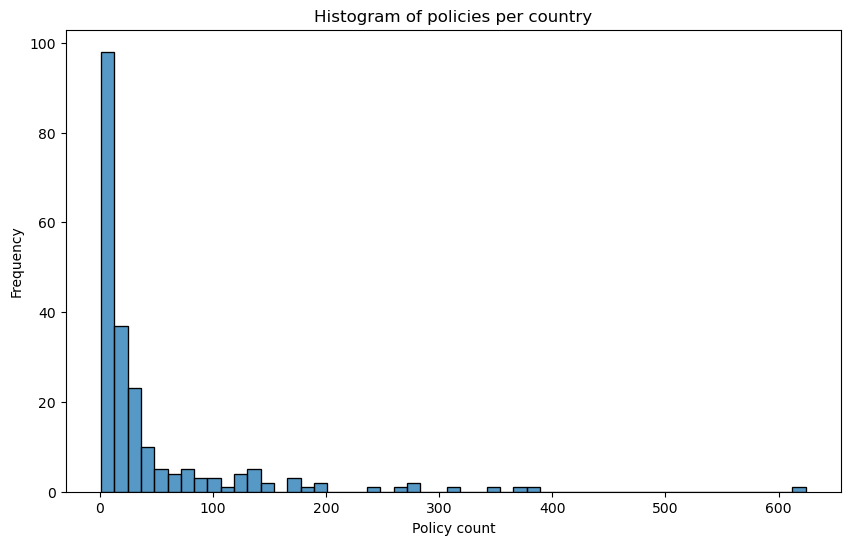

In [32]:
# Histogram of policies per country
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['policy_count'])
plt.title('Histogram of policies per country')
plt.xlabel('Policy count')
plt.ylabel('Frequency')
plt.show()


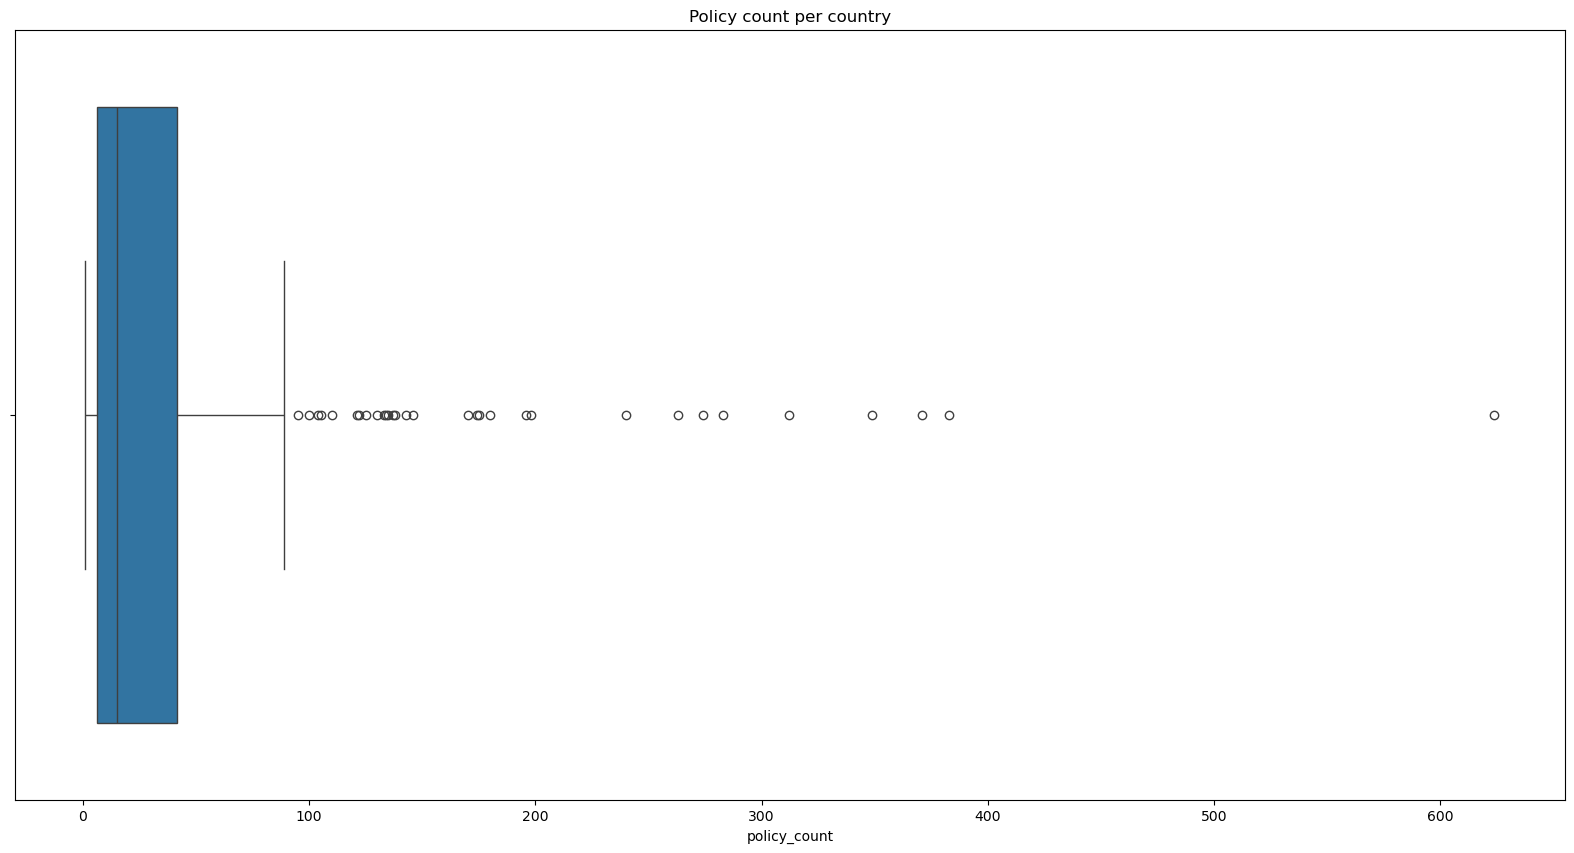

In [33]:
# Boxplot of policy count per country
plt.figure(figsize=(20, 10))
sns.boxplot(data=policies_per_country_df, x='policy_count')
plt.title('Policy count per country')
plt.show()

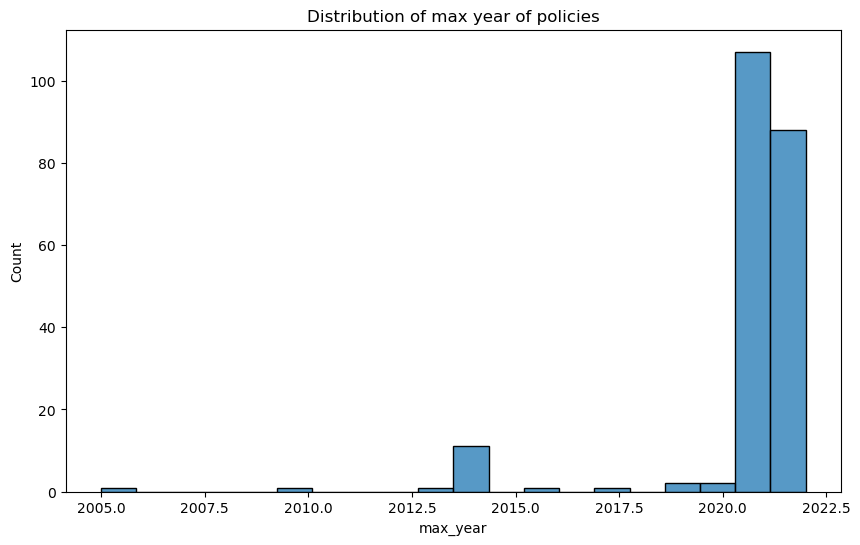

In [34]:
# Plot distribution of max_year
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['max_year'], bins=20)
plt.title('Distribution of max year of policies')
plt.show()

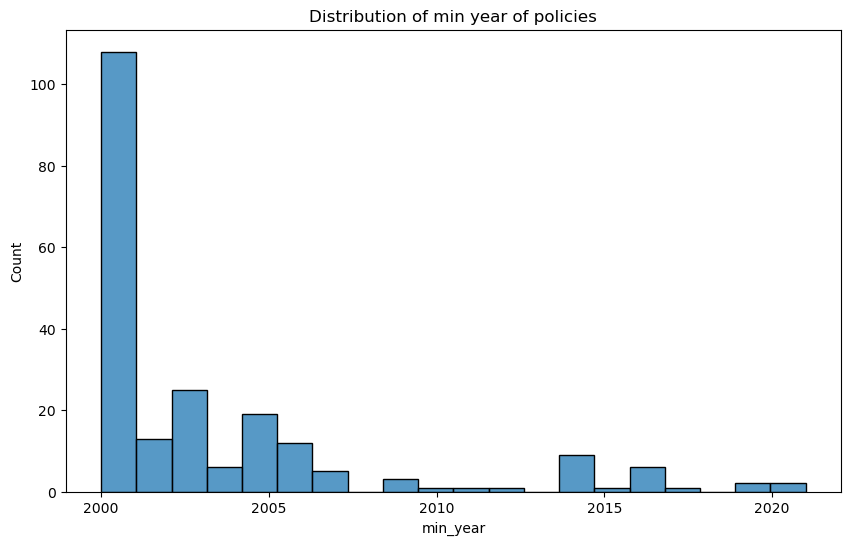

In [35]:
# Plot distribution of min_year
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['min_year'], bins=20)
plt.title('Distribution of min year of policies')
plt.show()

In [36]:
IEA_policies_df.columns

Index(['year', 'jurisdiction', 'title', 'description', 'status', 'iso3',
       'country', 'topic', 'type', 'category'],
      dtype='object')

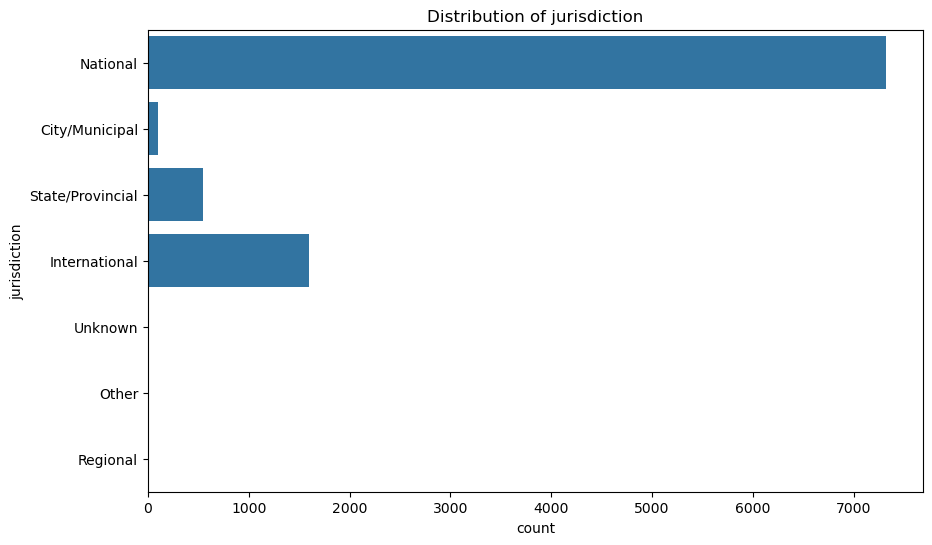

In [37]:
# Plot distribution of jurisdiction
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='jurisdiction')
plt.title('Distribution of jurisdiction')
plt.show()

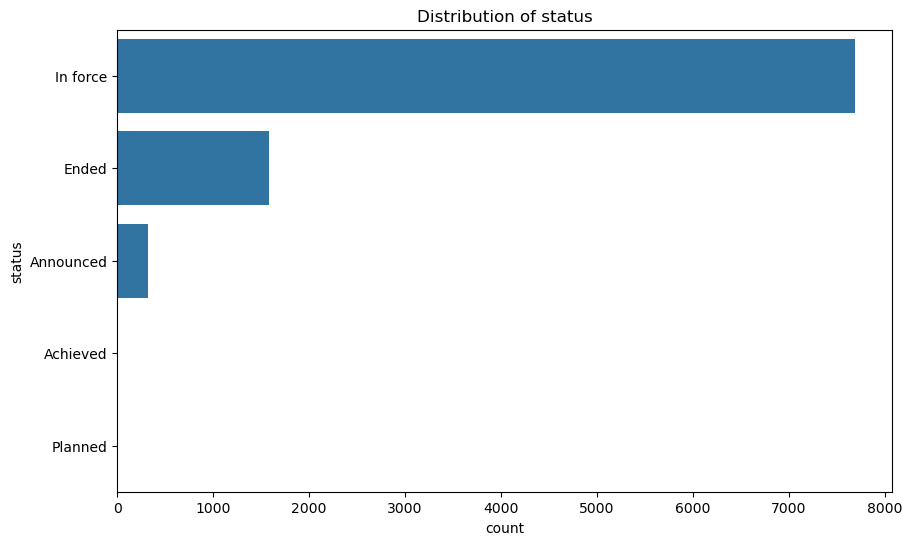

In [38]:
# Plot distribution of status
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='status')
plt.title('Distribution of status')
plt.show()


In [39]:
# topic	type	category	
print('Amount of types: ', len(IEA_policies_df['type'].unique()))
print('Amount of categories: ',len(IEA_policies_df['category'].unique()))
print('Amount of topics: ', len(IEA_policies_df['topic'].unique()))

Amount of types:  378
Amount of categories:  155
Amount of topics:  64


- **Simple Count/Score:**
For each country and year, count the number of active policies or sum their weighted scores.
    - **Pros:** Simple, transparent.
    - **Cons:** May oversimplify policy heterogeneity.
- **Composite Index:**
Combine multiple dimensions (e.g., type, intensity, status) into a single score using techniques like Principal Component Analysis (PCA) or factor analysis.
    - **Pros:** Captures multiple dimensions in a data-driven way.
    - **Cons:** Interpretation might be more challenging.